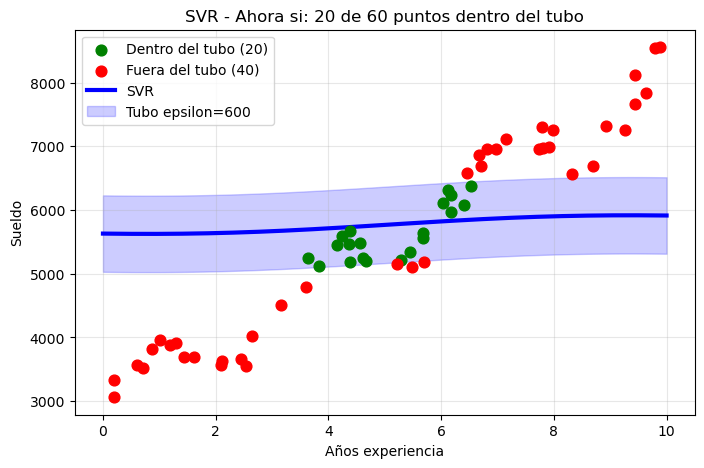

In [2]:
# svr-auditoria-salarial

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Datos
np.random.seed(0)
X = np.sort(np.random.rand(60,1)*10, axis=0)
y = 3000 + X.ravel()*500 + np.sin(X.ravel()*2)*400 + np.random.randn(60)*200

scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

# AHORA SI - tubo ancho para que entren los puntos
epsilon = 600
svr = SVR(kernel='rbf', gamma=0.3, C=10.0, epsilon=epsilon)
svr.fit(X_norm, y)

# Prediccion
X_test = np.linspace(0,10,200).reshape(-1,1)
y_pred = svr.predict(scaler.transform(X_test))
y_pred_train = svr.predict(X_norm)

# Clasificamos puntos dentro/fuera del tubo
dentro = np.abs(y - y_pred_train) <= epsilon

# Grafica final bonita
plt.figure(figsize=(8,5))
plt.scatter(X[dentro], y[dentro], color='green', s=60, label=f'Dentro del tubo ({dentro.sum()})', zorder=3)
plt.scatter(X[~dentro], y[~dentro], color='red', s=60, label=f'Fuera del tubo ({(~dentro).sum()})', zorder=3)

plt.plot(X_test, y_pred, color='blue', linewidth=3, label='SVR')
plt.fill_between(X_test.ravel(), y_pred-epsilon, y_pred+epsilon, color='blue', alpha=0.2, label=f'Tubo epsilon={epsilon}')

plt.title(f'SVR - Ahora si: {dentro.sum()} de 60 puntos dentro del tubo')
plt.xlabel('Años experiencia')
plt.ylabel('Sueldo')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('svr_puntos_bonitos.png')
plt.show()